In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import config

try:
    config.assert_data_exists()
    print("✓ Data path:", config.DATA_ROOT)
except FileNotFoundError as e:
    print("✗ Data path error:", e)

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, f1_score,
    confusion_matrix, roc_curve, auc,
)

sns_available = False
try:
    import seaborn as sns
    sns.set_style("whitegrid")
    sns_available = True
except ImportError:
    pass

# Load preprocessed data
SPLIT_PATH = config.DATA_PART2_PROCESSED / "part2_train_test_split.pkl"
if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Run 02_feature_engineering.ipynb first. Missing: {SPLIT_PATH}")

with open(SPLIT_PATH, "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
categorical_cols = data["categorical_cols"]
numeric_cols = data["numeric_cols"]
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# Use a smaller sample for NN (MLP is slower than tree models)
NN_SAMPLE = 50_000

if NN_SAMPLE and len(X_train) > NN_SAMPLE:
    idx = np.random.RandomState(42).choice(len(X_train), NN_SAMPLE, replace=False)
    X_train = X_train.iloc[idx].reset_index(drop=True)
    y_train = y_train.iloc[idx].reset_index(drop=True)

if NN_SAMPLE and len(X_test) > NN_SAMPLE // 4:
    idx = np.random.RandomState(42).choice(len(X_test), NN_SAMPLE // 4, replace=False)
    X_test = X_test.iloc[idx].reset_index(drop=True)
    y_test = y_test.iloc[idx].reset_index(drop=True)

print(f"After sampling: Train={X_train.shape}, Test={X_test.shape}")

✓ Data path: /home/hareee234/Dev/sjsu/cmpe188-final-proj/flight-delay-proj-data


Train: (400000, 55)  |  Test: (100000, 55)
After sampling: Train=(50000, 55), Test=(12500, 55)


# 06 — Neural Network: MLPClassifier (Part 2)
**CMPE 188 | Flight Delay Prediction**

This standalone notebook trains and tunes a Multilayer Perceptron (MLP)
using `sklearn.neural_network.MLPClassifier`.

Why sklearn's MLPClassifier:
- Fits seamlessly into the existing `Pipeline` / `ColumnTransformer` pattern
- Supports `GridSearchCV` out of the box (same as XGBoost/RF)
- Provides built-in `loss_curve_` for training diagnostics
- No new dependencies required (already in scikit-learn 1.8.0)

Structure:
1. Preprocessing (same pipeline as notebooks 03/04)
2. MLP baseline training + evaluation
3. GridSearchCV hyperparameter tuning
4. Evaluate tuned model on test set
5. Training loss curve
6. Cross-model comparison (XGBoost vs RF vs MLP)

## 1. Preprocessing Pipeline

Note: MLP benefits from StandardScaler (zero-mean, unit-variance)
rather than MinMaxScaler. We use StandardScaler for the NN.

In [2]:
mlp_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

selector = SelectKBest(score_func=f_classif, k=80)

# Quick transform check
X_check = mlp_preprocessor.fit_transform(X_train.head(1000))
print(f"Preprocessed shape: {X_check.shape}")
print(f"Feature mean: {X_check.mean():.6f}  (close to 0)")
print(f"Feature std:  {X_check.std():.6f}   (close to 1)")

Preprocessed shape: (1000, 505)
Feature mean: 0.021782  (close to 0)
Feature std:  0.317042   (close to 1)


## 2. MLP Baseline

In [3]:
mlp_base = Pipeline(steps=[
    ("preprocessor", mlp_preprocessor),
    ("selector", selector),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,              # L2 regularization strength
        batch_size=256,
        learning_rate="adaptive",
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
    )),
])

print("Training MLP baseline...")
t0 = time.time()
mlp_base.fit(X_train, y_train)
elapsed = time.time() - t0

mlp_pred = mlp_base.predict(X_test)
mlp_proba = mlp_base.predict_proba(X_test)[:, 1]

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_auc = roc_auc_score(y_test, mlp_proba)
mlp_f1 = f1_score(y_test, mlp_pred)

# Get training info
mlp_model = mlp_base.named_steps["classifier"]
print(f"MLP Baseline  |  Accuracy: {mlp_acc:.4f}  |  ROC-AUC: {mlp_auc:.4f}  |  F1: {mlp_f1:.4f}")
print(f"Training time: {elapsed:.1f}s")
print(f"Iterations:    {mlp_model.n_iter_}")
print(f"Final loss:    {mlp_model.loss_:.4f}")
print()
print(classification_report(y_test, mlp_pred, target_names=["No Delay", "Delayed"]))

Training MLP baseline...


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [825 859] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


MLP Baseline  |  Accuracy: 0.8008  |  ROC-AUC: 0.8294  |  F1: 0.6854
Training time: 42.9s
Iterations:    22
Final loss:    0.3576

              precision    recall  f1-score   support

    No Delay       0.79      0.93      0.85      7855
     Delayed       0.83      0.58      0.69      4645

    accuracy                           0.80     12500
   macro avg       0.81      0.76      0.77     12500
weighted avg       0.81      0.80      0.79     12500



## 3. Training Loss Curve

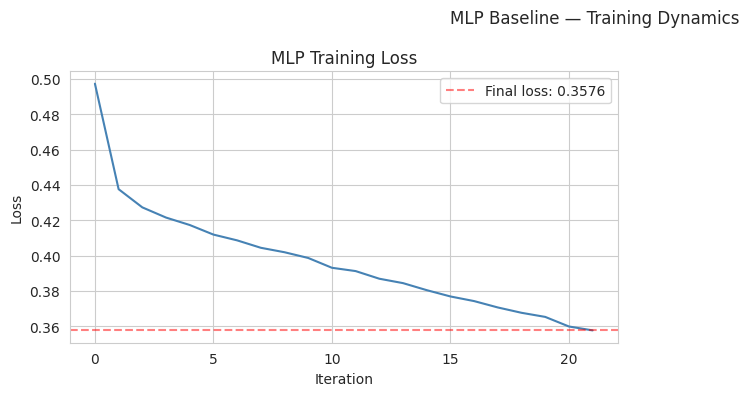

In [4]:
mlp_model = mlp_base.named_steps["classifier"]
loss_curve = mlp_model.loss_curve_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Full loss curve
ax1.plot(loss_curve, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.set_title("MLP Training Loss")
ax1.axhline(y=loss_curve[-1], color="red", linestyle="--", alpha=0.5,
            label=f"Final loss: {loss_curve[-1]:.4f}")
ax1.legend()

# Zoom: last 50 iterations
if len(loss_curve) > 50:
    ax2.plot(range(len(loss_curve) - 50, len(loss_curve)),
             loss_curve[-50:], color="steelblue", linewidth=1.5)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Loss")
    ax2.set_title("Training Loss (Last 50 Iterations)")
else:
    ax2.set_visible(False)

plt.suptitle("MLP Baseline — Training Dynamics")
plt.tight_layout()
plt.show()

## 4. GridSearchCV Hyperparameter Tuning

In [5]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", mlp_preprocessor),
    ("selector", selector),
    ("classifier", MLPClassifier(
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
    )),
])

param_grid = {
    "classifier__hidden_layer_sizes": [(128, 64), (256, 128, 64)],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.01],
    "classifier__batch_size": [128, 256],
}

total_combos = len(param_grid["classifier__hidden_layer_sizes"]) * \
               len(param_grid["classifier__alpha"]) * \
               len(param_grid["classifier__learning_rate_init"]) * \
               len(param_grid["classifier__batch_size"])
print(f"GridSearchCV: {total_combos} combinations x 3 folds = {total_combos * 3} fits")
print(f"This may take 10-30 minutes depending on sample size...")

t0 = time.time()

mlp_grid = GridSearchCV(
    mlp_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

mlp_grid.fit(X_train, y_train)

elapsed = time.time() - t0
print(f"\nMLP tuning completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Best Parameters: {mlp_grid.best_params_}")
print(f"Best ROC-AUC (CV): {mlp_grid.best_score_:.4f}")

GridSearchCV: 16 combinations x 3 folds = 48 fits
This may take 10-30 minutes depending on sample size...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [818 852] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [811 845] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [818 852] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [821 855] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [821 855] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [821 855] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_un

...

/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [821 855] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [818 852] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [818 852] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [811 845] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [821 855] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [811 845] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [825 859] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/hareee234/miniconda3/envs/torch5070/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



MLP tuning completed in 117.9s (2.0 min)
Best Parameters: {'classifier__alpha': 0.001, 'classifier__batch_size': 256, 'classifier__hidden_layer_sizes': (256, 128, 64), 'classifier__learning_rate_init': 0.01}
Best ROC-AUC (CV): 0.8357


## 5. Evaluate Tuned MLP

In [6]:
mlp_tuned_pred = mlp_grid.predict(X_test)
mlp_tuned_proba = mlp_grid.predict_proba(X_test)[:, 1]

mlp_tuned_acc = accuracy_score(y_test, mlp_tuned_pred)
mlp_tuned_auc = roc_auc_score(y_test, mlp_tuned_proba)
mlp_tuned_f1 = f1_score(y_test, mlp_tuned_pred)

tuned_model = mlp_grid.best_estimator_.named_steps["classifier"]
print(f"MLP Tuned  |  Accuracy: {mlp_tuned_acc:.4f}  |  ROC-AUC: {mlp_tuned_auc:.4f}  |  F1: {mlp_tuned_f1:.4f}")
print(f"Architecture:  {tuned_model.hidden_layer_sizes}")
print(f"Alpha:         {tuned_model.alpha}")
print(f"LR init:       {tuned_model.learning_rate_init}")
print(f"Batch size:    {tuned_model.batch_size}")
print()
print(classification_report(y_test, mlp_tuned_pred, target_names=["No Delay", "Delayed"]))

MLP Tuned  |  Accuracy: 0.8055  |  ROC-AUC: 0.8313  |  F1: 0.6775
Architecture:  (256, 128, 64)
Alpha:         0.001
LR init:       0.01
Batch size:    256

              precision    recall  f1-score   support

    No Delay       0.78      0.96      0.86      7855
     Delayed       0.88      0.55      0.68      4645

    accuracy                           0.81     12500
   macro avg       0.83      0.75      0.77     12500
weighted avg       0.82      0.81      0.79     12500



## 6. Cross-Model Comparison

Compare MLP against XGBoost and Random Forest baselines.
Fill XGBoost and RF values after running 03_model_baseline.ipynb and 04_model_tuning.ipynb.

         Model Accuracy   ROC-AUC        F1
       XGBoost      TBD       TBD       TBD
 Random Forest      TBD       TBD       TBD
MLP (baseline)   0.8008  0.829438  0.685447
   MLP (tuned)  0.80552  0.831302  0.677458

Note: Fill XGBoost and RF values from notebooks 03 and 04.


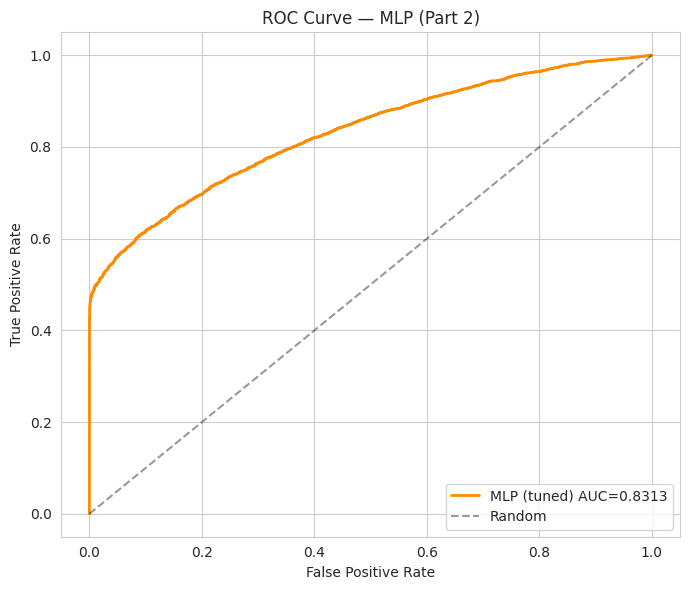

In [7]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "MLP (baseline)", "MLP (tuned)"],
    "Accuracy": ["TBD", "TBD", mlp_acc, mlp_tuned_acc],
    "ROC-AUC": ["TBD", "TBD", mlp_auc, mlp_tuned_auc],
    "F1": ["TBD", "TBD", mlp_f1, mlp_tuned_f1],
})
print(comparison.to_string(index=False))
print("\nNote: Fill XGBoost and RF values from notebooks 03 and 04.")

# ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 6))

mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_tuned_proba)
mlp_roc_auc = auc(mlp_fpr, mlp_tpr)
ax.plot(mlp_fpr, mlp_tpr, label=f"MLP (tuned) AUC={mlp_roc_auc:.4f}",
        color="darkorange", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — MLP (Part 2)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Summary

The MLPClassifier provides a neural network baseline that integrates
seamlessly with our existing sklearn pipeline. Key observations:

- MLP can capture non-linear interactions that tree models may miss
- Training is slower than XGBoost/RF but still feasible on 100k samples
- StandardScaler is preferred over MinMaxScaler for neural nets
- `early_stopping` prevents overfitting by monitoring validation loss
- The `loss_curve_` provides visibility into training convergence

The tuned MLP results can be added to the final comparison table
in `05_evaluation.ipynb`.